# Fracture Modeling

Dhaval Kadia, Brandon Nelson

This notebook introduces synthetic fractures, speficically *linear fractures*, see the definitions and figure below from [Cleveland Clinic](https://my.clevelandclinic.org/health/diseases/skull-fracture) for more details.

- **Linear fracture**: This is the most common type of skull fracture. It usually happens in the bone toward the top of your head, above your ears.
- **Depressed fracture**: A break in your skull that pushes part of the bone closer to your brain. A depressed fracture can involve multiple cracks and fragments.
- **Basal (basilar) fracture**: A break of the bones at the base of your skull. This includes the bones behind your face and the bones that are internal in your brain that you can’t see.
- **Diastatic fracture**: A separation of the cranial sutures, or the bands of tissue that connect the bones in your skull together.
- **Combination or complex fractures**: Fractures that may involve several of the above types or multiple areas of fractured bone.

<img src="https://my.clevelandclinic.org/-/scassets/images/org/health/articles/skull-fracture" width="300">

This notebooks describes step 1 Synthetic Data Generation of the fracture modeling subproject:

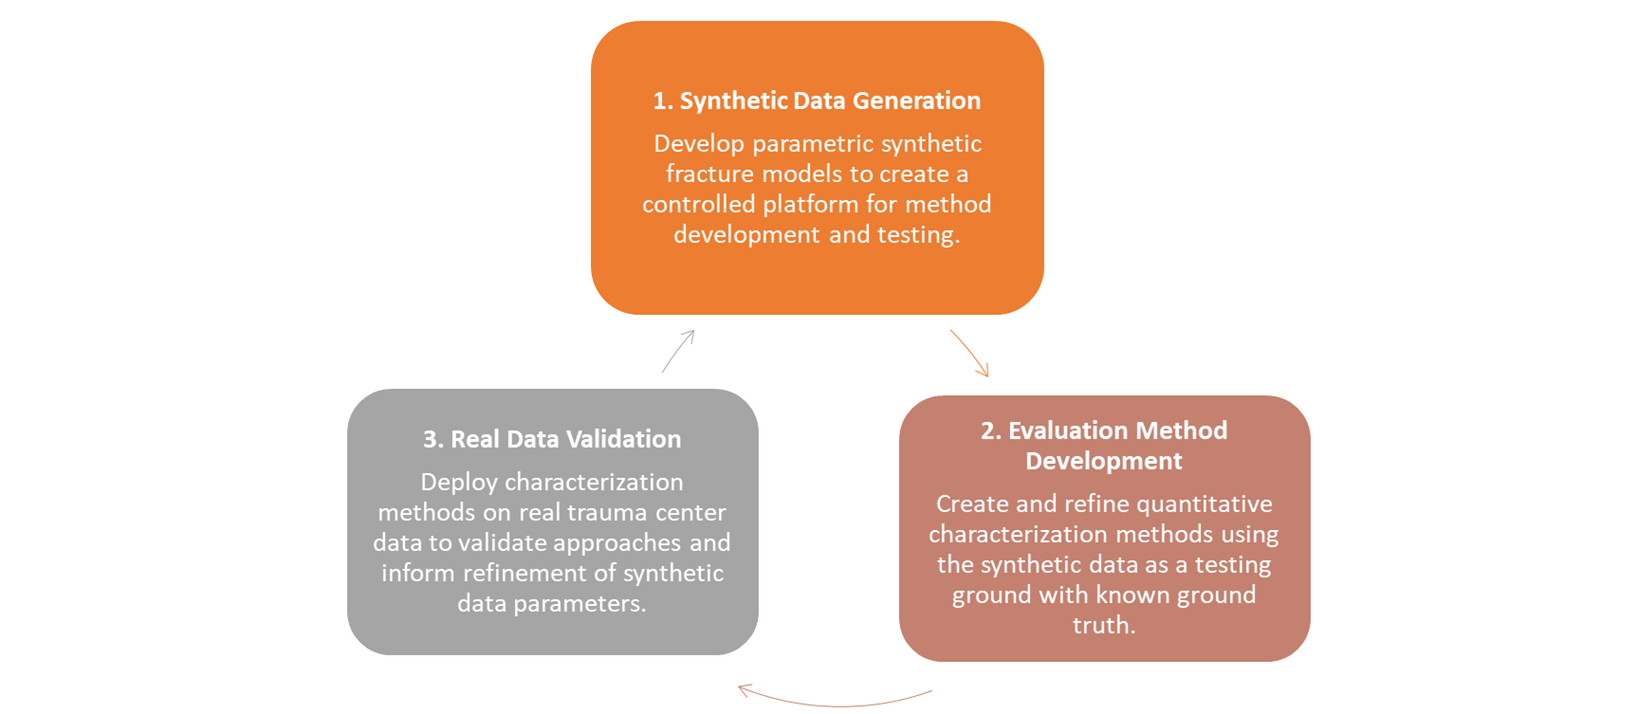

## Select a starting phantom

In [1]:
%pip install -q tomli-w pyvista pyransac3d

Note: you may need to restart the kernel to use updated packages.


In [2]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIH

In [3]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
phantom.add_fracture=True
# phantom.resize(3*[240]) NOTE_K: keeping original size
# phantom.insert_lesion('EDH', mass_effect=True, seed=42, intensity=80, volume=5, edema=1)

pseudo-CT images not found; defaulting to otsu segmentation method
5 198.38654320622294
Starting random walk fracture generation with 183 iterations
Skull centroid at: [ 98 116 107]
Casting rays with random walk...
Random walk ray casting complete!
5 254.51522517324005
Starting random walk fracture generation with 157 iterations
Skull centroid at: [ 98 116 107]
Casting rays with random walk...
Random walk ray casting complete!


It looks like this `thresh` argument is important in setting the distance of the fracture to skull. Since this threshold is used in projecting the fracture to the skull surface we should find a better way of setting this value, we could also adjust it to determine the depth of the fracture. Currently thresh is in units of pixels (since its a threshold of the distance transform). We can look into ways to make this unitless, either a fraction the head size or something like that so that it will continue to work even if the base phantom is resized.

55.069184238810585 339.69795593103436
Starting random walk fracture generation with 200 iterations
Skull centroid at: [ 98 116 107]
Casting rays with random walk...
Random walk ray casting complete!


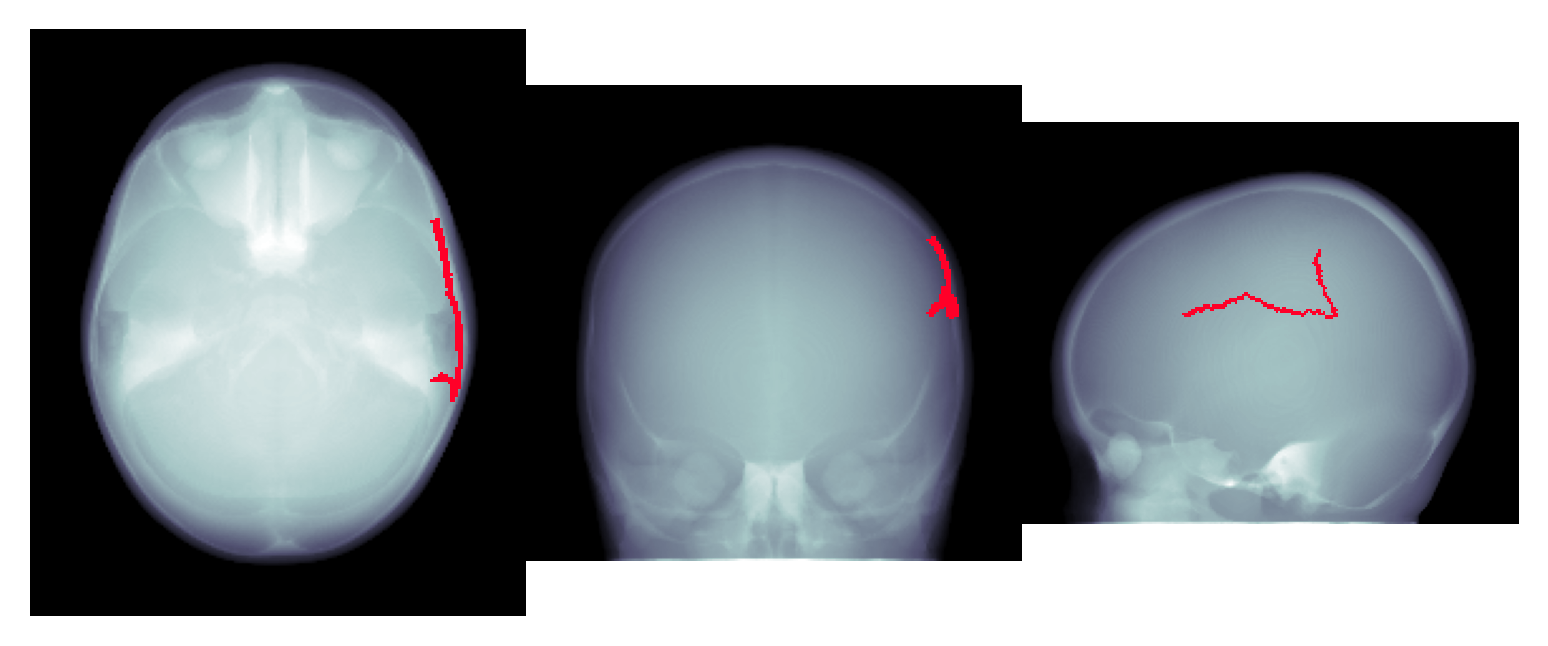

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fractures = phantom.get_fractures(length=200)
fracture_mask = np.ma.masked_where(fractures == 0, fractures)
phantom.add_fractures = False
vol = phantom.get_CT_number_phantom()

f, axs = plt.subplots(1, 3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
for i, ax in enumerate(axs):
    ax.imshow(vol.mean(axis=i), cmap='bone')
    ax.imshow(fracture_mask.mean(axis=i), cmap='gist_rainbow', interpolation='none')
    ax.axis('off')

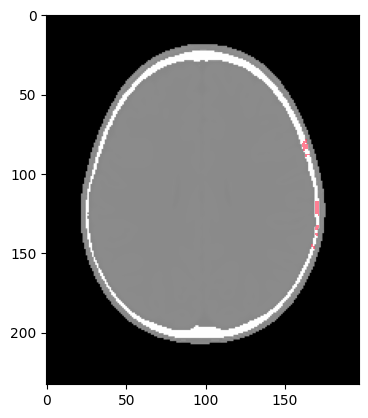

In [5]:
from skimage.measure import regionprops, label
from matplotlib import patches
c = 'g'

z_slice = fractures.mean(axis=(1,2)).argmax()
f, ax = plt.subplots()
ax.imshow(vol[z_slice], cmap='gray')
ax.imshow(fracture_mask[z_slice], cmap='gist_rainbow', interpolation='none', alpha=0.5)
# reg = regionprops(fractures.astype(np.uint8))[0]
# rect = patches.Rectangle((reg.bbox[1], reg.bbox[0]), reg.bbox[3] - reg.bbox[1],
#                           reg.bbox[2] - reg.bbox[0], linewidth=1, edgecolor=c, facecolor='none')
# ax.add_patch(rect)

13.602351562862928 346.42621290037783
Starting random walk fracture generation with 200 iterations
Skull centroid at: [ 98 116 107]
Casting rays with random walk...
Random walk ray casting complete!


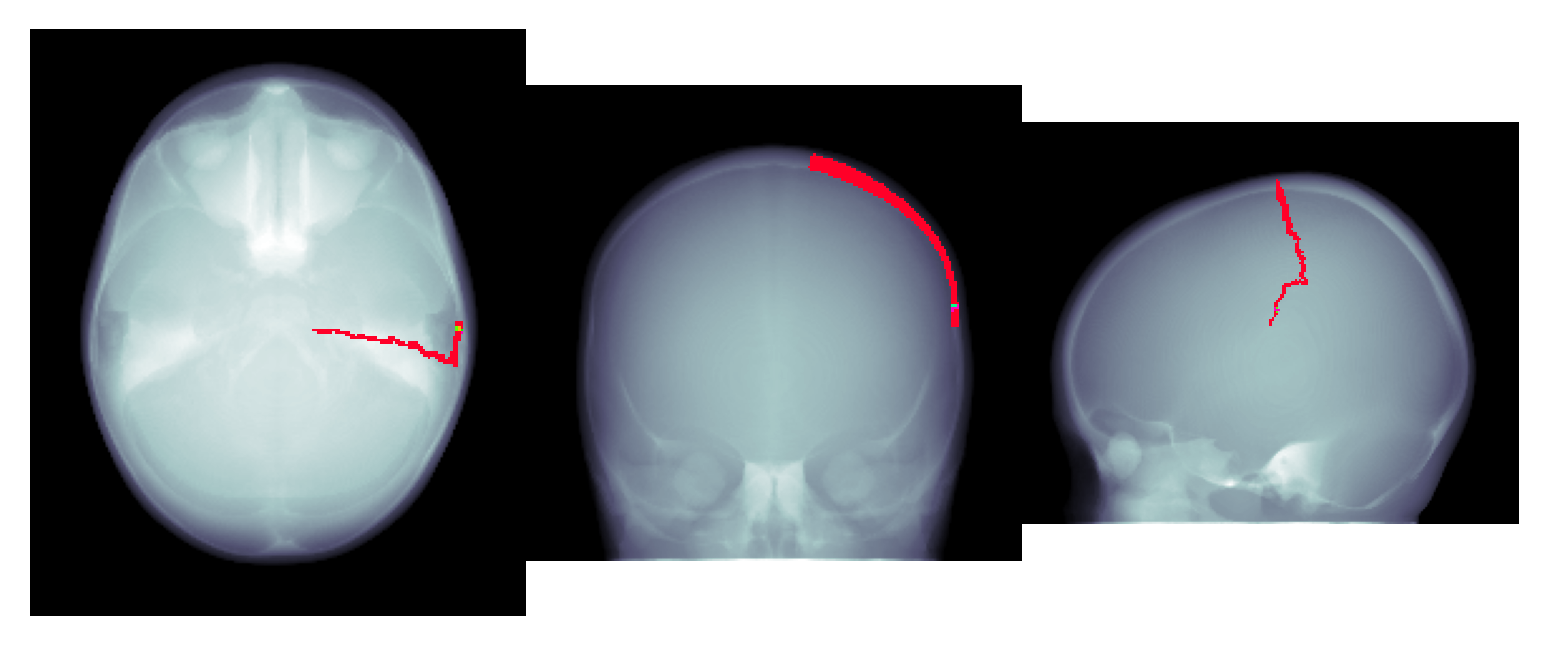

In [14]:
fracture_seg = phantom.fetch_fractures_seg(length=200, seed=8)
fracture_mask = np.ma.masked_where(fracture_seg == 0, fractures)

c = 'g'
f, axs = plt.subplots(1, 3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
for i, ax in enumerate(axs):
    ax.imshow(vol.mean(axis=i), cmap='bone')
    ax.imshow(fracture_mask.mean(axis=i), cmap='gist_rainbow', interpolation='none')
    ax.axis('off')